In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Cell 2 - آپلود دیتاست ZIP از کامپیوتر

from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

print("Uploaded file:", zip_file)

Saving archive.zip to archive.zip
Uploaded file: archive.zip


In [4]:
import os
import zipfile

zip_file = list(uploaded.keys())[0]

extract_path = "/content/cats_dogs"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed.")
print("Contents:")
print(os.listdir(extract_path))

Extraction completed.
Contents:
['cats_and_dogs_filtered']


In [5]:
# Cell 4 - تعیین مسیر دیتاست

PATH = "/content/cats_dogs/cats_and_dogs_filtered"

train_dir = os.path.join(PATH, "train")
validation_dir = os.path.join(PATH, "validation")

print("Dataset path:", PATH)
print("Train directory:", train_dir)
print("Validation directory:", validation_dir)

print("\nTrain classes:", os.listdir(train_dir))
print("Validation classes:", os.listdir(validation_dir))

Dataset path: /content/cats_dogs/cats_and_dogs_filtered
Train directory: /content/cats_dogs/cats_and_dogs_filtered/train
Validation directory: /content/cats_dogs/cats_and_dogs_filtered/validation

Train classes: ['cats', 'dogs']
Validation classes: ['cats', 'dogs']


In [6]:
# Cell 5 - تعداد تصاویر هر کلاس

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    print("Train -", class_name, ":", len(os.listdir(class_path)))

for class_name in os.listdir(validation_dir):
    class_path = os.path.join(validation_dir, class_name)
    print("Validation -", class_name, ":", len(os.listdir(class_path)))

Train - cats : 1000
Train - dogs : 1000
Validation - cats : 500
Validation - dogs : 500


In [7]:
# Cell 6 - تنظیمات تصاویر

IMG_SIZE = (160, 160)
BATCH_SIZE = 32
SEED = 123

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (160, 160)
Batch size: 32


In [8]:
# Cell 7 - ساخت Dataset با tf.data

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

print("Datasets created successfully.")

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Datasets created successfully.


In [9]:
# Cell 8 - نام کلاس‌ها

class_names = train_ds.class_names

print("Class names:", class_names)

Class names: ['cats', 'dogs']


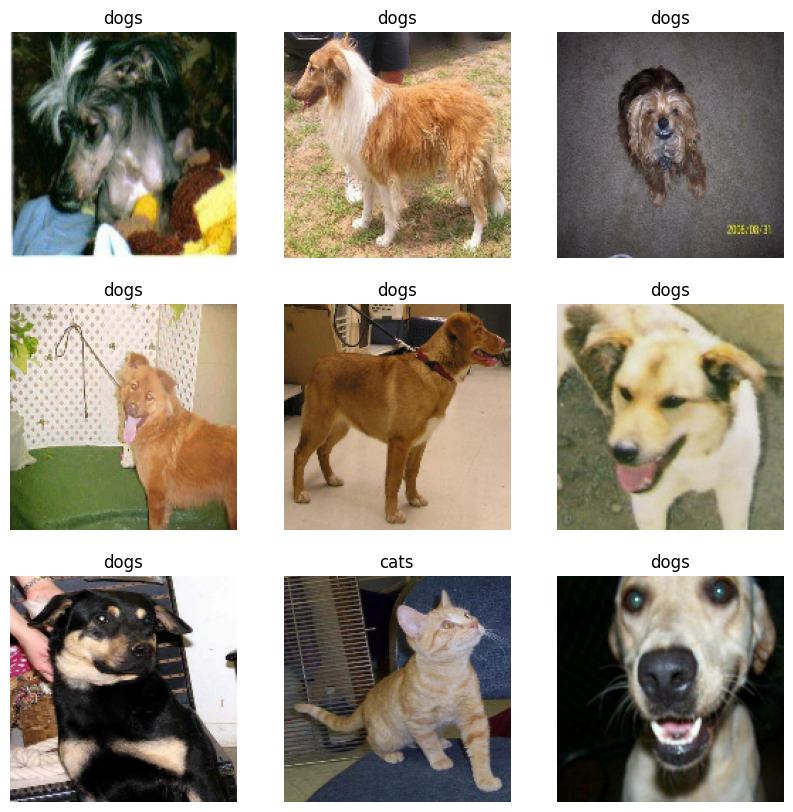

In [10]:
# Cell 9 - نمایش نمونه تصاویر

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [11]:
# Cell 10 - بهینه سازی سرعت با cache و prefetch

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(
    buffer_size=AUTOTUNE
)

validation_ds = validation_ds.cache().prefetch(
    buffer_size=AUTOTUNE
)

print("tf.data pipeline is ready.")

tf.data pipeline is ready.


In [12]:
# Cell 11 - افزایش داده

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

print("Data augmentation is ready.")

Data augmentation is ready.


In [13]:
# Cell 12 - ساخت مدل CNN

model = keras.Sequential([
    layers.Input(shape=(160, 160, 3)),

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,401,921 (20.61 MB)

 Trainable params: 5,401,921 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Cell 13 - کامپایل مدل

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [15]:
# Cell 14 - آموزش مدل

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15
)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.5280 - loss: 0.7074 - val_accuracy: 0.5150 - val_loss: 0.6844
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5860 - loss: 0.6687 - val_accuracy: 0.5350 - val_loss: 0.6842
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6105 - loss: 0.6504 - val_accuracy: 0.6260 - val_loss: 0.6460
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6255 - loss: 0.6406 - val_accuracy: 0.5910 - val_loss: 0.6377
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6870 - loss: 0.6001 - val_accuracy: 0.6300 - val_loss: 0.6406
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6665 - loss: 0.5978 - val_accuracy: 0.6340 - val_loss: 0.6431
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6860 - loss: 0.5928 - val_accuracy: 0.6730 - val_loss: 0.6058
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6960 - loss: 0.5803 - val_accuracy: 0.6600 - 

In [16]:
# Cell 15 - ارزیابی مدل

val_loss, val_accuracy = model.evaluate(validation_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7170 - loss: 0.5595
Validation Loss: 0.5595376491546631
Validation Accuracy: 0.7170000076293945


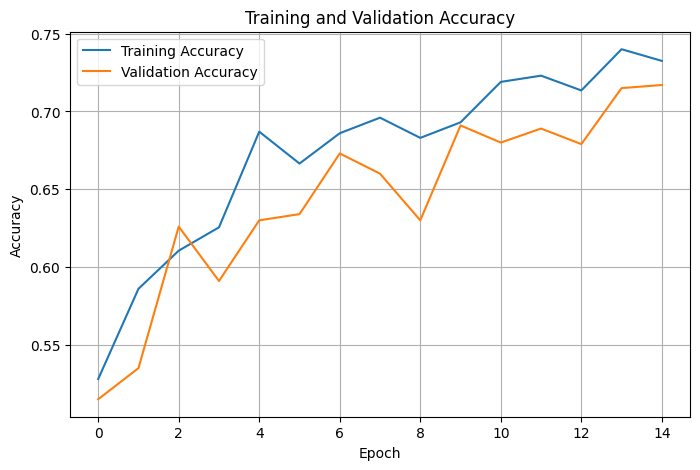

In [17]:
# Cell 16 - نمودار دقت

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

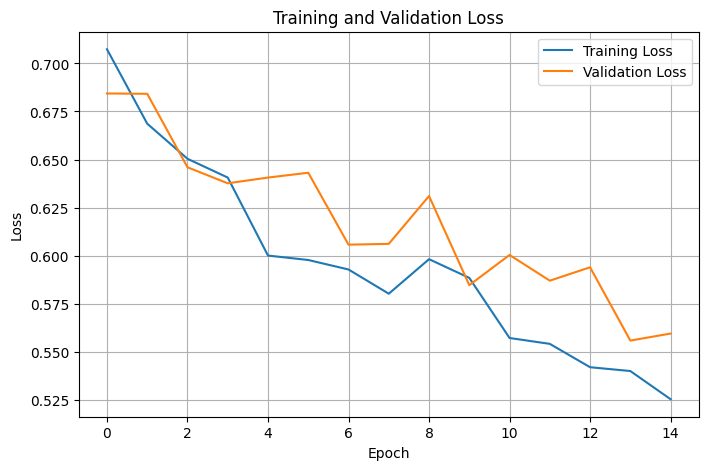

In [18]:
# Cell 17 - نمودار خطا

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

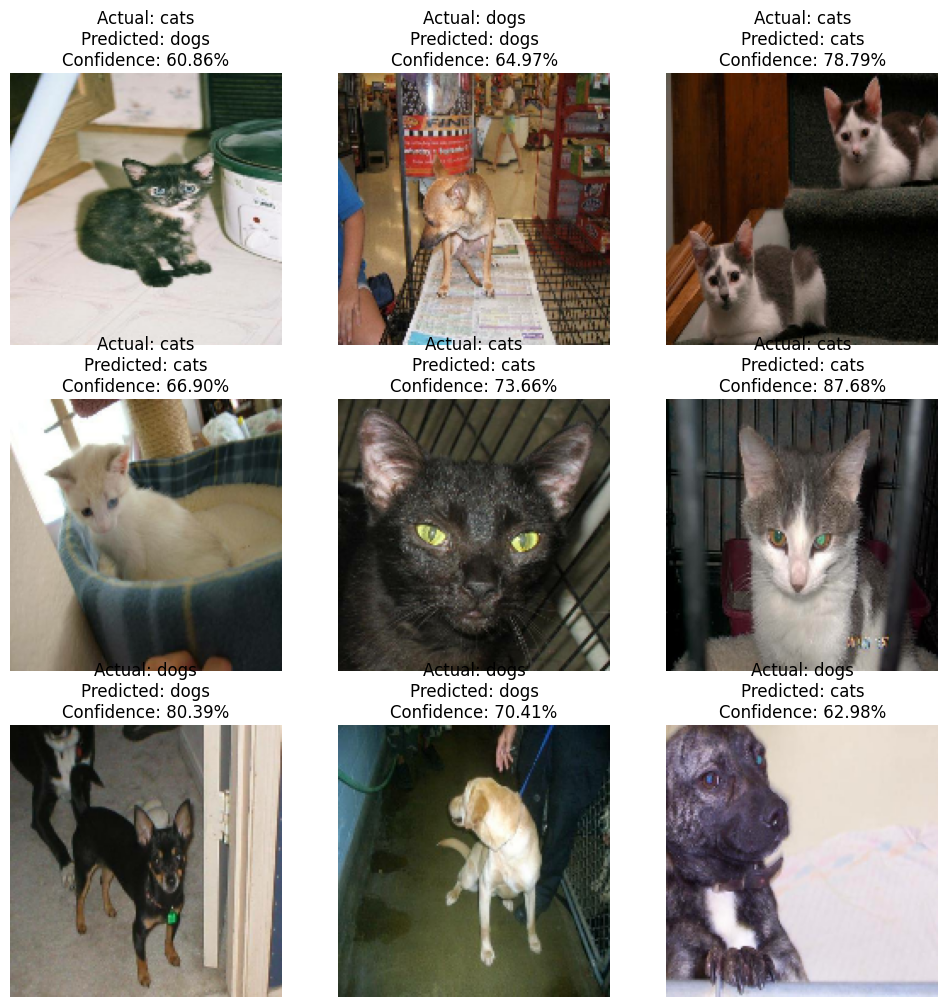

In [19]:
# Cell 18 - پیش بینی تصاویر

plt.figure(figsize=(12, 12))

for images, labels in validation_ds.take(1):

    predictions = model.predict(images, verbose=0)

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        probability = predictions[i][0]

        if probability >= 0.5:
            predicted_class = "dogs"
            confidence = probability
        else:
            predicted_class = "cats"
            confidence = 1 - probability

        actual_class = class_names[labels[i]]

        plt.title(
            f"Actual: {actual_class}\n"
            f"Predicted: {predicted_class}\n"
            f"Confidence: {confidence:.2%}"
        )

        plt.axis("off")

plt.show()

In [20]:
# Cell 19 - ذخیره مدل

model.save("/content/cats_dogs_tfdata.keras")

print("Model saved successfully.")

Model saved successfully.


In [21]:
# Cell 20 - خلاصه نهایی

print("=" * 50)
print("FINAL RESULT - CATS VS DOGS")
print("=" * 50)

print("Dataset: Cats vs Dogs")
print("Method: tf.data")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Model: CNN")
print("Validation Accuracy:", f"{val_accuracy:.4f}")
print("Validation Accuracy (%):", f"{val_accuracy * 100:.2f}%")
print("Model saved as: cats_dogs_tfdata.keras")
print("=" * 50)

FINAL RESULT - CATS VS DOGS
Dataset: Cats vs Dogs
Method: tf.data
Image size: (160, 160)
Batch size: 32
Model: CNN
Validation Accuracy: 0.7170
Validation Accuracy (%): 71.70%
Model saved as: cats_dogs_tfdata.keras
